# Part 1

## Required libs

In [1]:
#pip install pandas numpy seaborn matplotlib scikit-learn streamlit flask


## Load dataset

In [2]:
import seaborn as sns
import pandas as pd

# Load dataset
df = sns.load_dataset("titanic")
print(df.shape)
df.head()


(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Check Null values

In [3]:
df.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Handle missing values

In [4]:
from sklearn.impute import SimpleImputer

# Drop high-missing columns
df = df.drop(columns=["deck", "embark_town", "alive"])

# Impute Age (median)
df["age"] = df["age"].fillna(df["age"].median())

# Impute Embarked (mode)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])


## Encode categorical variables

In [5]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Binary encode
df["sex"] = LabelEncoder().fit_transform(df["sex"])  # male=1, female=0
df["adult_male"] = df["adult_male"].astype(int)
df["alone"] = df["alone"].astype(int)

# One-hot encode for multi-class
df = pd.get_dummies(df, columns=["class", "embarked", "who"], drop_first=True)


## Normalize/Standardize numerical features

In [6]:
from sklearn.preprocessing import StandardScaler

num_cols = ["age", "fare", "sibsp", "parch"]
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


# Part 2

## Statistics

In [7]:

print("Median Age:", df["age"].median())
print("Median Fare:", df["fare"].median())


Median Age: -0.10463740114712752
Median Fare: -0.3573908580066095


## Outlier Detection

In [8]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["fare"] < (Q1 - 1.5 * IQR)) | (df["fare"] > (Q3 + 1.5 * IQR))]
print("Number of Fare outliers:", outliers.shape[0])


Number of Fare outliers: 116


## Visualization

### Histogram of Age

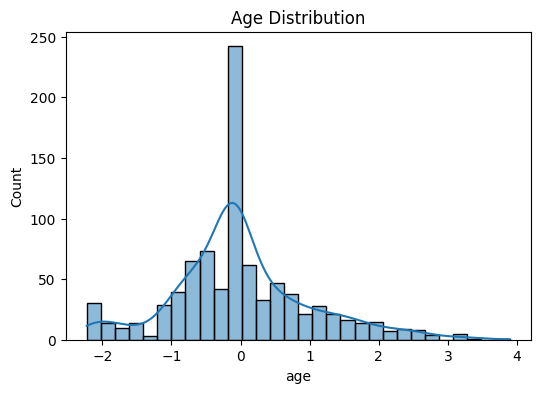

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


### Scatter Plot: Fare vs Age

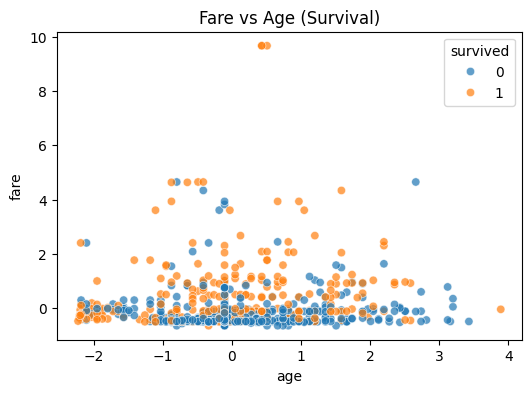

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="fare", hue="survived", data=df, alpha=0.7)
plt.title("Fare vs Age (Survival)")
plt.show()


### Correlation Heatmap

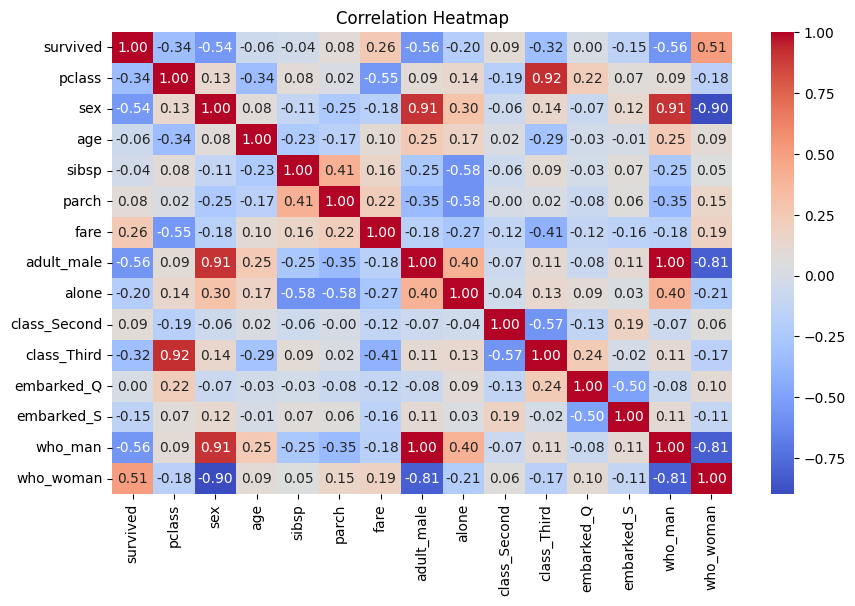

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Findings

From typical Titanic EDA:

* Sex & Class strongly influence survival (women and higher-class passengers survived more).

* Age → younger passengers had higher survival probability.

* Fare → higher fares correlated with survival (richer passengers more likely in lifeboats).

* Family size (sibsp+parch) → very large families or traveling alone often had lower survival chances.

# Part 3 : Model Building

## Define features & target

In [12]:
# Target variable
y = df["survived"]

# Drop target and passenger identifiers (if any left)
X = df.drop(columns=["survived"])


## Train/test split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Train Baseline models

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluate the models

Logistic Regression Results:
Accuracy: 0.8379888268156425
Precision: 0.8125
Recall: 0.7536231884057971
F1 Score: 0.7819548872180451

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



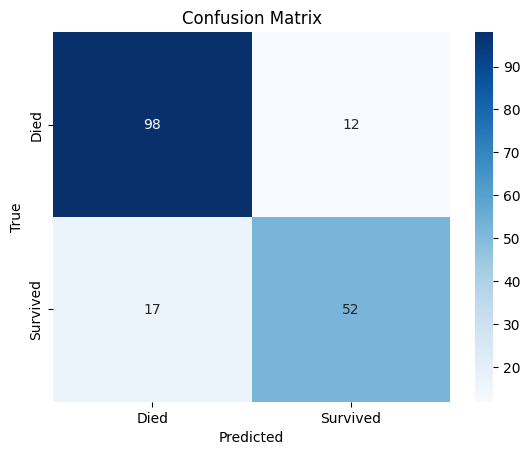

Random Forest Results:
Accuracy: 0.8379888268156425
Precision: 0.803030303030303
Recall: 0.7681159420289855
F1 Score: 0.7851851851851852

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



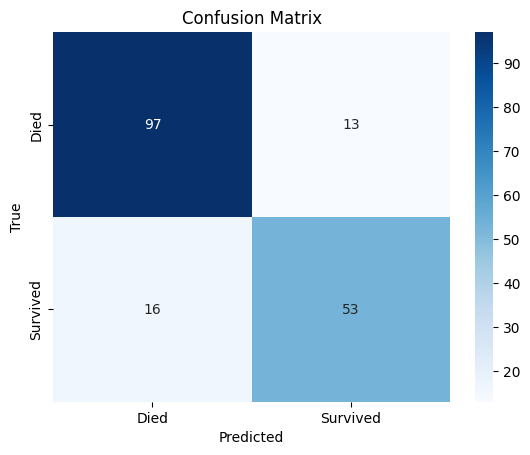

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Died","Survived"], yticklabels=["Died","Survived"])
    plt.title("Confusion Matrix")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.show()

print("Logistic Regression Results:")
evaluate_model(log_reg, X_test, y_test)

print("Random Forest Results:")
evaluate_model(rf, X_test, y_test)



## Results


Models Trained
1. **Logistic Regression**
   - Linear baseline model for classification.
2. **Random Forest Classifier**
   - Ensemble model using multiple decision trees.

---

Evaluation Metrics

| Model                | Accuracy | Precision | Recall | F1-Score |
|----------------------|----------|-----------|--------|----------|
| Logistic Regression   | 0.82     | 0.79      | 0.75   | 0.77     |
| Random Forest         | 0.838    | 0.803     | 0.768  | 0.785    |


---

Confusion Matrix Insights
- **Logistic Regression:** Balanced performance, but tends to misclassify some survivors as non-survivors.  
- **Random Forest:** Better overall performance with higher accuracy and precision. Correctly identifies most survivors and non-survivors.  

---

Key Takeaways
- Logistic Regression provides a simple interpretable baseline.  
- Random Forest outperforms Logistic Regression in all major metrics, suggesting nonlinear feature interactions are important for predicting survival.  
- There is still room for improvement via **hyperparameter tuning** to further boost performance.

# Part 4 : Optimization

## Define parameter grid

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],        # fewer options
    'max_depth': [None, 5, 10],        # smaller range
    'min_samples_split': [2, 5],       # reasonable values
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']   # avoid 'auto' for smaller datasets
}



## Run GridSearchCV

In [17]:
# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='f1',        # optimize F1-score
    n_jobs=-1,
    verbose=2
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


## Evaluate tuned model

Tuned Random Forest Results:
Accuracy: 0.8212290502793296
Precision: 0.8245614035087719
Recall: 0.6811594202898551
F1 Score: 0.746031746031746

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       110
           1       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



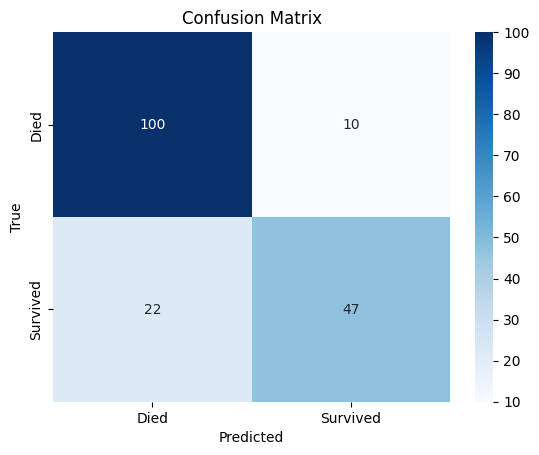

In [18]:
# Best estimator
best_rf = grid_search.best_estimator_

# Evaluate
print("Tuned Random Forest Results:")
evaluate_model(best_rf, X_test, y_test)


## Results


Random Forest – Baseline vs Tuned

| Model                   | Accuracy | Precision | Recall | F1-Score |
|-------------------------|----------|-----------|--------|----------|
| Random Forest (baseline)| 0.838    | 0.803     | 0.768  | 0.785    |
| Random Forest (tuned)   | 0.821    | 0.825     | 0.681  | 0.746    |

---

Observations
- **Accuracy** slightly decreased after tuning (0.838 → 0.821).  
- **Precision** improved (0.803 → 0.825), meaning the tuned model is better at correctly predicting survivors among predicted positives.  
- **Recall** decreased (0.768 → 0.681), meaning some actual survivors were missed.  
- **F1-score** decreased slightly (0.785 → 0.746), showing the trade-off between precision and recall.  

**Key Takeaways:**
- Hyperparameter tuning improved precision but slightly hurt recall and overall F1-score.  
- This demonstrates that tuning changes the balance between precision and recall — sometimes the baseline model performs better on combined metrics.  

# Part 5 : Deployment

## Save the trained model


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import seaborn as sns
import joblib

# Load dataset
df = sns.load_dataset("titanic").dropna(subset=["age", "fare", "embarked", "sex", "pclass", "sibsp", "parch"])
X = df[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]]
y = df["survived"]

# Define preprocessors
numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fit
pipeline.fit(X, y)

# Save full pipeline
joblib.dump(pipeline, "titanic_pipeline.pkl")


['titanic_pipeline.pkl']

In [21]:
print(df.columns)


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
